# Process 1 — event log split into material flow + machine activities, and the energy curves of one activity

Rebuilds the two blocks of the paper figure, straight from the simulated process-1 event log
and one pipeline run:

1. **Material-flow layer** — the station-to-station route of a batch (`Water_supply → Destillation →
   Bottling → autoclaving_{1,2,3} → Individual_packaging → Warehousing`), autoclaving split into its
   parallel machines.
2. **Machine-activity layer** — the internal activities of ONE machine (`FOCUS_OBJECT`, default
   `autoclaving_3`): `prepare → heat → hold → cool`.
3. **Energy curves per machine activity** — every occurrence of that activity in the chosen case set,
   plotted against its own real elapsed time (no resampling, no barycenter).

The case set is the **test split of the pipeline run** (`RUN`), read from that run's own
`predicted_logs/<process>_test_set.parquet`, so the split is identical to the one the run evaluated on.

**Real vs simulated curves** — only `CURVE_SOURCE` changes:

| `CURVE_SOURCE`   | curves                                                                 |
|------------------|------------------------------------------------------------------------|
| `real_expanded`  | real sensor readings from the gold `df_expanded` (what this run shows)  |
| `run_real`       | `real` series of the run's saved curve file — cross-check of the above  |
| `run_predicted`  | `predicted` series of one approach — the **simulated** test curves      |

`run_*` needs a run with saved curves (`save_predicted_curves: True` in `pipeline.py`). Check which
runs under `results/` have `complete_curve_eval_results/<process>/<mode>/predicted_curves*.parquet`
and point `RUN` / `SIM_MODE` / `SIM_APPROACH` at one of them (section 8 below lists what the current
run has to offer).

Sections 1–7 build the single figure for the **real** version. Section 9 rebuilds the exact same
figure for the **simulated** version (predicted curves) using the config set in section 8 — it
doesn't just change the variables, it re-derives everything downstream of them (`run_dir`, the test
split, both nets, the curves, the panels) so the simulated process model and profiles actually
render instead of silently reusing the real run's data. The notebook produces exactly **two images**:
the real paper figure and the simulated one.


In [1]:
# ── Config ───────────────────────────────────────────────────────────────────
RUN             = 'experiment_976'   # dir under ../results: full name or any substring (latest match)
DATA_EXPERIMENT = '1'                # gold data experiment that run was fed with
PROCESS         = 'process_1'
SPLIT           = 'test'             # 'test' | 'train' | 'all'  — which cases the curves come from
FOCUS_OBJECT    = 'autoclaving_3'    # the machine the machine-activity layer zooms into

# Curve panels: (activity, sensor).  None = auto-pick the dominant sensor of every
# FOCUS_OBJECT activity that has one.
PANELS = [
    ('autoclaving_3_heat', 'autoclave_steam_demand_kW_energy_to_model'),
    ('autoclaving_3_hold', 'autoclave_steam_demand_kW_energy_to_model'),
    ('autoclaving_3_cool', 'autoclave_cooling_water_demand_kW_energy_to_model'),
]

# ── Where the curves come from ───────────────────────────────────────────────
CURVE_SOURCE = 'real_expanded'   # 'real_expanded' | 'run_real' | 'run_predicted'

# Only used by 'run_real' / 'run_predicted':
SIM_SCOPE    = 'complete'        # 'complete' → complete_curve_eval_results/<process>/<SIM_MODE>/
                                 # 'schedule' → schedule_profile_eval_results/<process>/
SIM_MODE     = 'petri_net_heuristic_ml_plus_per_act'   # net + duration-model directory
SIM_APPROACH = 'ml_external'     # curve approach; '' → predicted_curves.parquet
SIM_SERIES   = None              # None → 'real' for run_real, 'predicted' for run_predicted.
                                 # 'schedule' scope also has: schedule, stochastic, bootstrap,
                                 # best, best_duration_corrected, best_budget
SIM_LOG      = 'auto'            # which log gives the activity windows:
                                 # 'auto' → real test log for real/schedule/stochastic/bootstrap,
                                 #          predicted_logs/<process>_<SIM_MODE>.parquet otherwise
                                 # 'real' | 'sim' to force it

# ── Plotting ─────────────────────────────────────────────────────────────────
MAX_CURVES   = 60                # occurrences drawn per panel (None = all)
NET_DPI      = 200               # graphviz render resolution for the two nets
NET_MARGIN   = 0.1               # graphviz page margin, inches (used to place the arrows)
OUT_DIR      = 'visuals/process_and_profiles'
SAVE         = True


In [2]:
import re
import tempfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.gridspec as gridspec
from IPython.display import Image, display

import pm4py
from pm4py.algo.discovery.heuristics import algorithm as heuristics_miner
from pm4py.visualization.heuristics_net import visualizer as hn_vis

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white', 'savefig.facecolor': 'white',
    'font.size': 10, 'axes.titlesize': 11, 'axes.labelsize': 10, 'legend.fontsize': 9,
    'axes.spines.top': False, 'axes.spines.right': False, 'figure.dpi': 130,
})

REPO    = next(d for d in [Path.cwd(), *Path.cwd().parents]
               if (d / 'results').is_dir() and (d / 'data').is_dir())   # repo root, from anywhere
RESULTS = REPO / 'results'
GOLD    = REPO / 'data' / 'gold' / f'experiment_{DATA_EXPERIMENT}' / PROCESS / 'datasets'
OUT     = Path(OUT_DIR)
if SAVE:
    OUT.mkdir(parents=True, exist_ok=True)

_matches = [d for d in sorted(RESULTS.iterdir()) if d.is_dir() and (d.name == RUN or RUN in d.name)]
assert _matches, f'no run under {RESULTS} matching {RUN!r}'
run_dir = _matches[-1]

df_event_log = pd.read_parquet(GOLD / 'df_event_log.parquet')
df_expanded  = pd.read_parquet(GOLD / 'df_expanded.parquet')

SENSOR_COLS = [c for c in df_expanded.columns if c.endswith('_energy_to_model')]

print(f'run   : {run_dir.name}' + ('' if RUN == run_dir.name else f'   (latest match for {RUN!r})'))
print(f'gold  : {GOLD.relative_to(REPO)}')
print(f'log   : {len(df_event_log)} events, {df_event_log["case_id"].nunique()} cases, '
      f'{df_event_log["activity"].nunique()} activities')
print(f'energy: {len(df_expanded)} rows, {len(SENSOR_COLS)} sensors')


run   : experiment_976_20260726_103126   (latest match for 'experiment_976')
gold  : data/gold/experiment_1/process_1/datasets
log   : 41275 events, 2190 cases, 25 activities
energy: 271056 rows, 7 sensors


## 1. Case set — the run's own test split

Taken from `predicted_logs/<process>_test_set.parquet` when the run wrote one (exact same split the run
evaluated on); otherwise re-derived as the temporal split at the ratio printed in that run's
`pipeline_execution.log`.


In [3]:
_all_cases  = set(df_event_log['case_id'].dropna().unique())
_test_path  = run_dir / 'predicted_logs' / f'{PROCESS}_test_set.parquet'

if _test_path.exists():
    test_cases  = set(pd.read_parquet(_test_path)['case_id'].dropna().unique())
    split_source = f'predicted_logs/{PROCESS}_test_set.parquet'
else:
    _log = (run_dir / 'pipeline_execution.log')
    _m = re.search(r'SPLIT \((\d+)% train', _log.read_text()) if _log.exists() else None
    _ratio = int(_m.group(1)) / 100 if _m else 0.80
    _case_start = df_event_log.groupby('case_id')['timestamp_start'].min().sort_values()
    _n_train = max(1, int(len(_case_start) * _ratio))
    test_cases = set(_case_start.index[_n_train:])
    split_source = f'temporal split re-derived at train_ratio={_ratio:.2f} (run saved no test set)'

train_cases = _all_cases - test_cases
cases = {'test': test_cases, 'train': train_cases, 'all': _all_cases}[SPLIT]

print(f'split source : {split_source}')
print(f'train / test : {len(train_cases)} / {len(test_cases)} cases')
print(f'SPLIT={SPLIT!r} → {len(cases)} cases used below')


split source : predicted_logs/process_1_test_set.parquet
train / test : 2100 / 90 cases
SPLIT='test' → 90 cases used below


## 2. Split the event log into the two layers

* **material flow** — one node per station, but the station `FOCUS_OBJECT` belongs to (`Autoclaving`) is
  broken up into its machines, so the parallel branches show up. Consecutive repeats of the same node are
  collapsed, so the edges are the station-to-station handovers of a batch.
* **machine activities** — every event of `FOCUS_OBJECT` only, at activity level.


In [4]:
el = (df_event_log[df_event_log['case_id'].isin(cases)]
      .sort_values(['case_id', 'timestamp_start'])
      .copy())

_focus_rows = el[el['object'] == FOCUS_OBJECT]
assert len(_focus_rows), f'{FOCUS_OBJECT!r} does not appear in this case set'
MACHINE_STATION = _focus_rows['station'].iloc[0]

# ── material-flow layer ──────────────────────────────────────────────────────
df_material = el.copy()
df_material['flow_node'] = np.where(df_material['station'] == MACHINE_STATION,
                                    df_material['object'], df_material['station'])
_prev = df_material.groupby('case_id')['flow_node'].shift(1)
df_material = df_material[df_material['flow_node'] != _prev].copy()

# ── machine-activity layer ───────────────────────────────────────────────────
df_machine = el[el['object'] == FOCUS_OBJECT].copy()

# activities of the focus machine, in process order (mean position within its own trace)
_order = (df_machine.assign(pos=df_machine.groupby('case_id').cumcount())
          .groupby('activity')['pos'].mean().sort_values())
MACHINE_ACTIVITIES = list(_order.index)

print(f'material flow  : {len(df_material)} handovers, nodes = '
      f'{list(df_material["flow_node"].value_counts().index)}')
print(f'machine layer  : {len(df_machine)} events on {FOCUS_OBJECT} '
      f'({df_machine["case_id"].nunique()} cases)')
print(f'  activities in process order: {MACHINE_ACTIVITIES}')
display(df_machine.groupby('activity').size().rename('events').to_frame().T)


material flow  : 612 handovers, nodes = ['Warehousing', 'Individual_packaging', 'Water_supply', 'Destillation', 'Bottling', 'autoclaving_2', 'autoclaving_3', 'autoclaving_1']
machine layer  : 137 events on autoclaving_3 (31 cases)
  activities in process order: ['autoclaving_3_prepare', 'autoclaving_3_heat', 'autoclaving_3_hold', 'autoclaving_3_cool']


activity,autoclaving_3_cool,autoclaving_3_heat,autoclaving_3_hold,autoclaving_3_prepare
events,35,35,35,32


## 3a. Material-flow net


saved visuals/process_and_profiles/net_material_flow_process_1_test.pdf


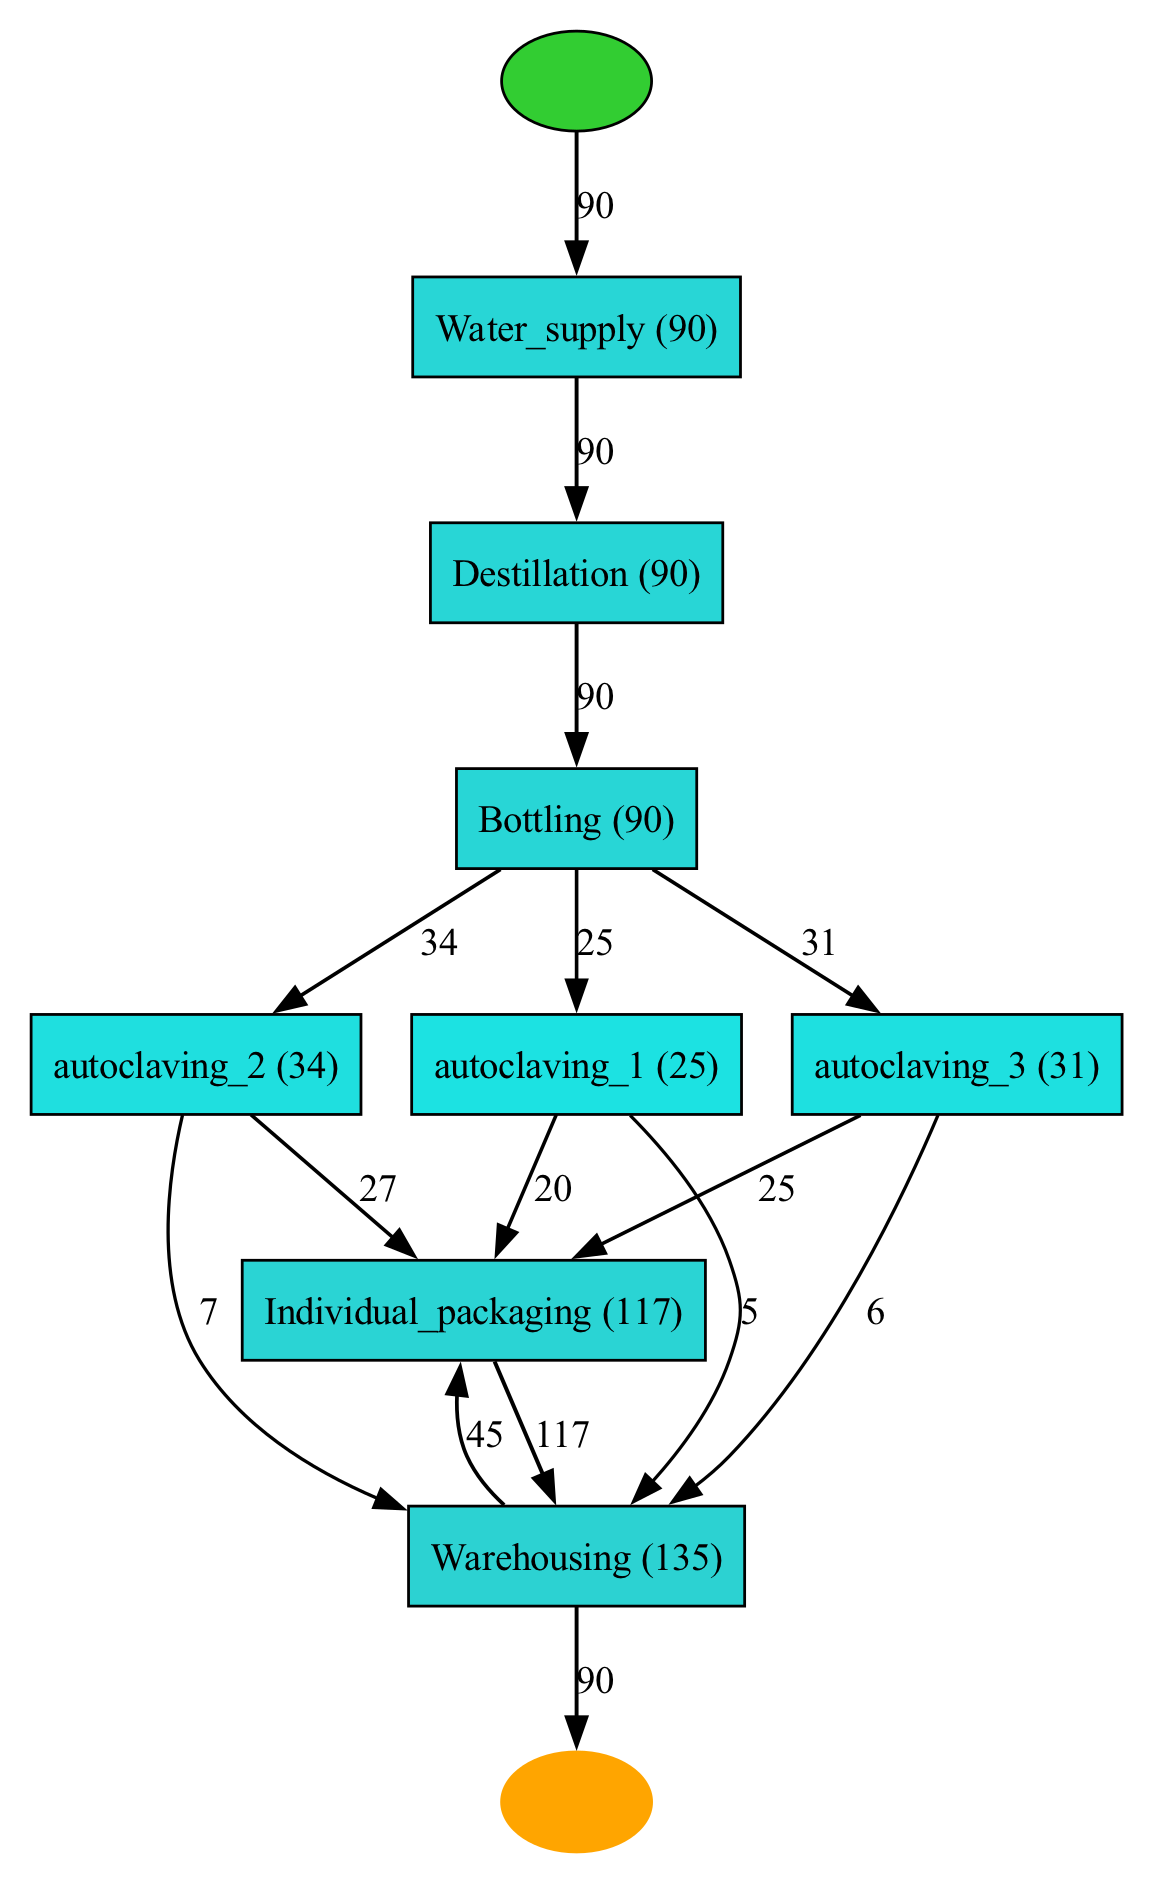

In [5]:
def load_net_image(png):
    """Read a graphviz PNG and flatten it onto white -- its page margin is transparent,
    which otherwise shows up as a faint rectangle around the net."""
    im = mpimg.imread(png)
    if im.ndim == 3 and im.shape[2] == 4:
        rgb, alpha = im[..., :3], im[..., 3:4]
        im = rgb * alpha + (1.0 - alpha)
    return im


def _to_pm4py(df, activity_col):
    d = df.rename(columns={'case_id': 'case:concept:name',
                           activity_col: 'concept:name',
                           'timestamp_start': 'time:timestamp'})
    d = d[['case:concept:name', 'concept:name', 'time:timestamp']].copy()
    d['time:timestamp'] = pd.to_datetime(d['time:timestamp'])
    return pm4py.convert_to_event_log(d)


def heuristic_net(df, activity_col, pdf_name=None, **heu_kwargs):
    """Mine + render a heuristics net.  Returns (png_path, gviz) — the graphviz object is
    kept so cell 7b can read the node coordinates back out of it."""
    log = _to_pm4py(df, activity_col)
    net = heuristics_miner.apply_heu(log, parameters=heu_kwargs or None)
    gviz = hn_vis.apply(net)
    try:                                  # sharper rendering + a known margin
        gviz.graph_attr['dpi'] = str(NET_DPI)
        gviz.graph_attr['margin'] = str(NET_MARGIN)
    except Exception:
        pass
    png = tempfile.NamedTemporaryFile(suffix='.png', delete=False).name
    hn_vis.save(gviz, png)
    if SAVE and pdf_name:
        # hn_vis.save() writes PNG bytes whatever the extension -- render vector via graphviz
        gviz.render(str(OUT / Path(pdf_name).stem), format='pdf', cleanup=True)
        print(f'saved {OUT / pdf_name}')
    return png, gviz


png_material, gviz_material = heuristic_net(df_material, 'flow_node',
                                            f'net_material_flow_{PROCESS}_{SPLIT}.pdf')
display(Image(filename=png_material))


## 3b. Machine-activity net (`FOCUS_OBJECT`)


saved visuals/process_and_profiles/net_machine_autoclaving_3_test.pdf


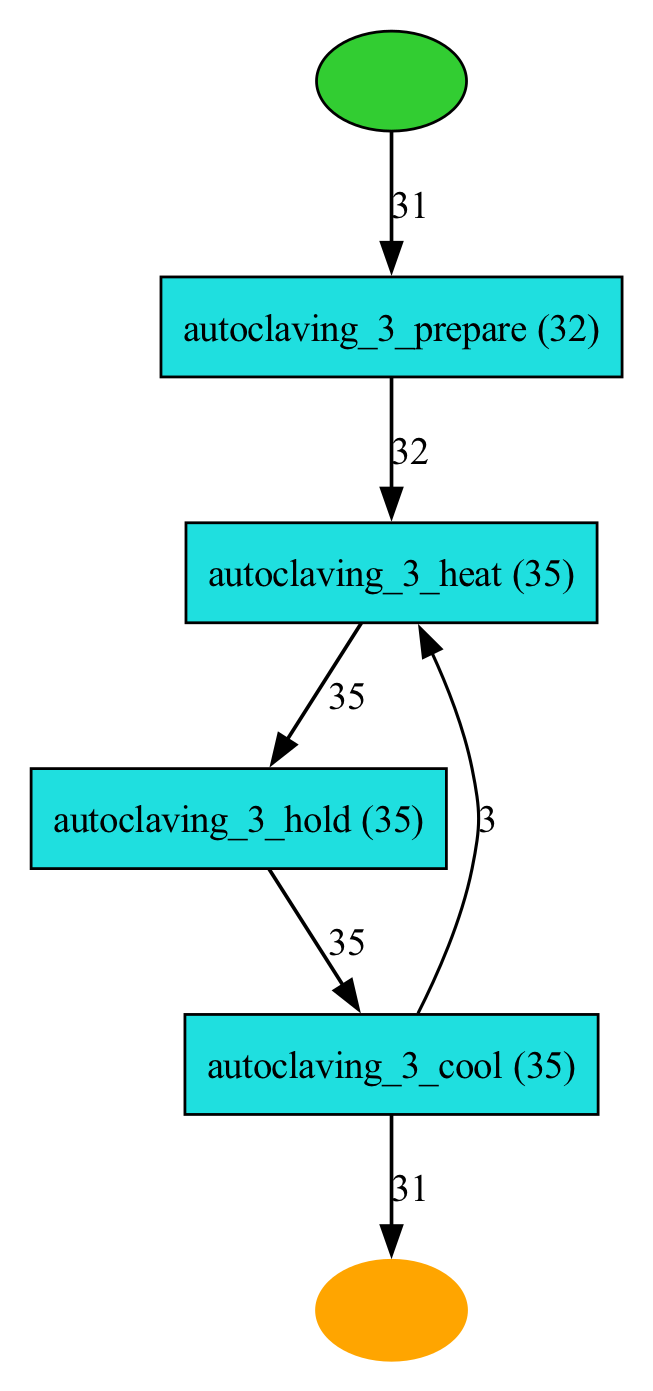

In [6]:
png_machine, gviz_machine = heuristic_net(df_machine, 'activity',
                                          f'net_machine_{FOCUS_OBJECT}_{SPLIT}.pdf')
display(Image(filename=png_machine))


## 4. Curve extraction

One curve per **occurrence** of an activity (not per case — a machine can run several cycles for the same
batch), taken from whichever source `CURVE_SOURCE` selects:

* `real_expanded` — rows of `df_expanded` labelled with that activity, grouped by
  `(case_id_log, timestamp_start_log)`, i.e. one group per event-log occurrence.
* `run_real` / `run_predicted` — the run's `predicted_curves*.parquet` (`case_id, sensor, series,
  t_minutes, value`, minutes since that curve's own case start), sliced by the activity windows of the
  matching log: the real test log for the real/schedule-driven series, the approach's own
  `predicted_logs/<process>_<SIM_MODE>.parquet` for the simulated series (its curves follow its own
  simulated schedule).


In [7]:
# Tolerance when slicing a run curve by an activity window, minutes.  Keep it at 0: back-to-back
# activities are only seconds apart, so any slack pulls the NEXT activity's first sample into the
# curve -- e.g. a hold curve flat at 22 kW ending on one 4007 kW sample of the following heat.
_EPS_MIN = 0.0
_curve_cache = {}


def curves_real_expanded(activity, sensor):
    """Returns a list of (t_minutes, value) pairs, t_minutes elapsed since the occurrence started."""
    sub = df_expanded[(df_expanded['activity_log'] == activity)
                      & (df_expanded['case_id_log'].isin(cases))].sort_values('datetime_energy')
    out = []
    for _, g in sub.groupby(['case_id_log', 'timestamp_start_log'], sort=True):
        v = g[sensor].to_numpy(dtype=float)
        t = (g['datetime_energy'] - g['datetime_energy'].iloc[0]).dt.total_seconds().to_numpy() / 60
        mask = np.isfinite(v)
        v, t = v[mask], t[mask]
        if len(v) > 2:
            out.append((t, v))
    return out


def _run_curve_path():
    if SIM_SCOPE == 'complete':
        d = run_dir / 'complete_curve_eval_results' / PROCESS / SIM_MODE
    else:
        d = run_dir / 'schedule_profile_eval_results' / PROCESS
    if not d.exists():
        _runs_with_curves = sorted({p.relative_to(RESULTS).parts[0]
                                    for p in RESULTS.glob('*/**/predicted_curves*.parquet')})
        raise AssertionError(f'{d} does not exist — this run saved no curves for that scope/mode.\n'
                             f'Runs that did: {_runs_with_curves}')
    for name in ([f'predicted_curves_{SIM_APPROACH}.parquet'] if SIM_APPROACH else []) + ['predicted_curves.parquet']:
        if (d / name).exists():
            return d / name
    raise AssertionError(f'no predicted_curves file for SIM_APPROACH={SIM_APPROACH!r} in {d}.\n'
                         f'available: {sorted(p.name for p in d.glob("predicted_curves*.parquet"))}')


def _run_curves_df():
    if 'curves' not in _curve_cache:
        p = _run_curve_path()
        _curve_cache['curves'] = pd.read_parquet(p)
        print(f'curves from {p.relative_to(run_dir)}  '
              f'| series: {sorted(_curve_cache["curves"]["series"].unique())}')
    return _curve_cache['curves']


def _window_log(series):
    use_real = (SIM_LOG == 'real') or (SIM_LOG == 'auto' and
                                       series in ('real', 'schedule', 'stochastic', 'bootstrap'))
    p = (run_dir / 'predicted_logs' /
         (f'{PROCESS}_test_set.parquet' if use_real else f'{PROCESS}_{SIM_MODE}.parquet'))
    assert p.exists(), f'{p} missing — cannot place activity windows for series {series!r}'
    key = ('log', p.name)
    if key not in _curve_cache:
        log = pd.read_parquet(p)
        log['timestamp_start'] = pd.to_datetime(log['timestamp_start'])
        log['timestamp_end']   = pd.to_datetime(log['timestamp_end'])
        _curve_cache[key] = log
        print(f'windows from predicted_logs/{p.name}')
    return _curve_cache[key]


def curves_from_run(activity, sensor, series):
    """Returns a list of (t_minutes, value) pairs, t_minutes elapsed since the activity started."""
    dfc = _run_curves_df()
    assert series in set(dfc['series']), \
        f'series {series!r} not in file (have {sorted(dfc["series"].unique())})'
    dfc = dfc[(dfc['sensor'] == sensor) & (dfc['series'] == series)]
    if dfc.empty:
        return []
    by_case = {c: g.sort_values('t_minutes') for c, g in dfc.groupby('case_id')}

    log = _window_log(series)
    log = log[log['case_id'].isin(cases)]
    case_t0 = log.groupby('case_id')['timestamp_start'].min()

    out = []
    occ = log[log['activity'] == activity].sort_values(['case_id', 'timestamp_start'])
    for _, r in occ.iterrows():
        g = by_case.get(r['case_id'])
        if g is None:
            continue
        t0 = case_t0[r['case_id']]
        a = (r['timestamp_start'] - t0).total_seconds() / 60
        b = (r['timestamp_end']   - t0).total_seconds() / 60
        sel = g.loc[g['t_minutes'].between(a - _EPS_MIN, b + _EPS_MIN)]
        v = sel['value'].to_numpy(dtype=float)
        t = sel['t_minutes'].to_numpy(dtype=float) - a
        mask = np.isfinite(v)
        v, t = v[mask], t[mask]
        if len(v) > 2:
            out.append((t, v))
    return out


def get_curves(activity, sensor):
    if CURVE_SOURCE == 'real_expanded':
        return curves_real_expanded(activity, sensor)
    series = SIM_SERIES or ('real' if CURVE_SOURCE == 'run_real' else 'predicted')
    return curves_from_run(activity, sensor, series)


# label that ends up in titles and file names
if CURVE_SOURCE == 'real_expanded':
    SOURCE_TAG, SOURCE_LABEL = 'real', 'real (gold expanded)'
else:
    _series = SIM_SERIES or ('real' if CURVE_SOURCE == 'run_real' else 'predicted')
    SOURCE_TAG   = f'{_series}_{SIM_MODE}' + (f'_{SIM_APPROACH}' if SIM_APPROACH else '')
    SOURCE_LABEL = f'{_series} — {SIM_MODE}' + (f' / {SIM_APPROACH}' if SIM_APPROACH else '')
print(f'CURVE_SOURCE={CURVE_SOURCE!r} → {SOURCE_LABEL}')


CURVE_SOURCE='real_expanded' → real (gold expanded)


## 5. Panels — which (activity, sensor) pairs to draw

With `PANELS = None` each activity of the focus machine gets the sensor whose peak is highest during that
activity, and activities whose curves are flat/zero are dropped.


In [8]:
def dominant_sensor(activity):
    sub = df_expanded[(df_expanded['activity_log'] == activity)
                      & (df_expanded['case_id_log'].isin(cases))]
    if sub.empty:
        return None
    peaks = {c: float(sub[c].max()) for c in SENSOR_COLS}
    best = max(peaks, key=peaks.get)
    return best if peaks[best] > 0 else None


if PANELS is None:
    panels = [(a, s) for a in MACHINE_ACTIVITIES if (s := dominant_sensor(a))]
else:
    panels = list(PANELS)

for a, s in panels:
    print(f'  {a:<28} {s}')


  autoclaving_3_heat           autoclave_steam_demand_kW_energy_to_model
  autoclaving_3_hold           autoclave_steam_demand_kW_energy_to_model
  autoclaving_3_cool           autoclave_cooling_water_demand_kW_energy_to_model


## 6. Curve data per panel

Extracted here, plotted only in the paper figure below (section 7) — no separate per-panel plot, no
barycenter/average, each occurrence keeps its own real elapsed time.


In [9]:
def draw_panel(ax, activity, sensor, curves, n_total):
    for t, v in curves:
        ax.plot(t, v, color='blue', alpha=0.15, lw=0.9)
    short = sensor.replace('_energy_to_model', '')
    ax.set_title(f'{activity} — {short}')
    ax.set_xlabel('Time since activity start (min)')
    ax.set_ylabel(short)
    ax.text(0.99, 0.02, f'n={len(curves)}' + ('' if len(curves) == n_total else f' of {n_total}'),
            transform=ax.transAxes, ha='right', va='bottom', fontsize=8, color='0.35')


panel_data = {}
for activity, sensor in panels:
    curves = get_curves(activity, sensor)
    if len(curves) < 2:
        print(f'!! {activity} / {sensor}: only {len(curves)} curve(s) — skipped')
        continue
    n_total = len(curves)
    used = curves[:MAX_CURVES] if MAX_CURVES else curves
    panel_data[(activity, sensor)] = dict(curves=used, n_total=n_total)
    print(f'{activity:<28} {sensor:<45} n={len(used)}' + ('' if len(used) == n_total else f' of {n_total}'))


autoclaving_3_heat           autoclave_steam_demand_kW_energy_to_model     n=35
autoclaving_3_hold           autoclave_steam_demand_kW_energy_to_model     n=35
autoclaving_3_cool           autoclave_cooling_water_demand_kW_energy_to_model n=35


## 7. Paper figure — machine net **on** the material flow, arrows from the activities to their profiles

The only figure this notebook renders: the material flow fills the left block with the `FOCUS_OBJECT`
net sitting on its top-right corner (a leader line ties it back to that machine's own box in the
material flow), and each profile on the right is connected by a red arrow that stops right at the
profile's y-axis title, not crossing over any tick labels or plot text.

Arrow anchors come from graphviz itself — the mined net is asked for its `plain` layout, which gives the
box coordinates of every node, so an arrow starts at the real `autoclaving_3_heat` box edge and not at a
hard-coded pixel. Nodes that cannot be located fall back to the right edge of the machine-net box.
Curves are plotted on their own real elapsed time (minutes since the activity started) — no
resampling, no barycenter.


machine-net nodes located: ['autoclaving_3_cool', 'autoclaving_3_heat', 'autoclaving_3_hold', 'autoclaving_3_prepare']


saved visuals/process_and_profiles/paper_figure_process_1_autoclaving_3_real_test.pdf


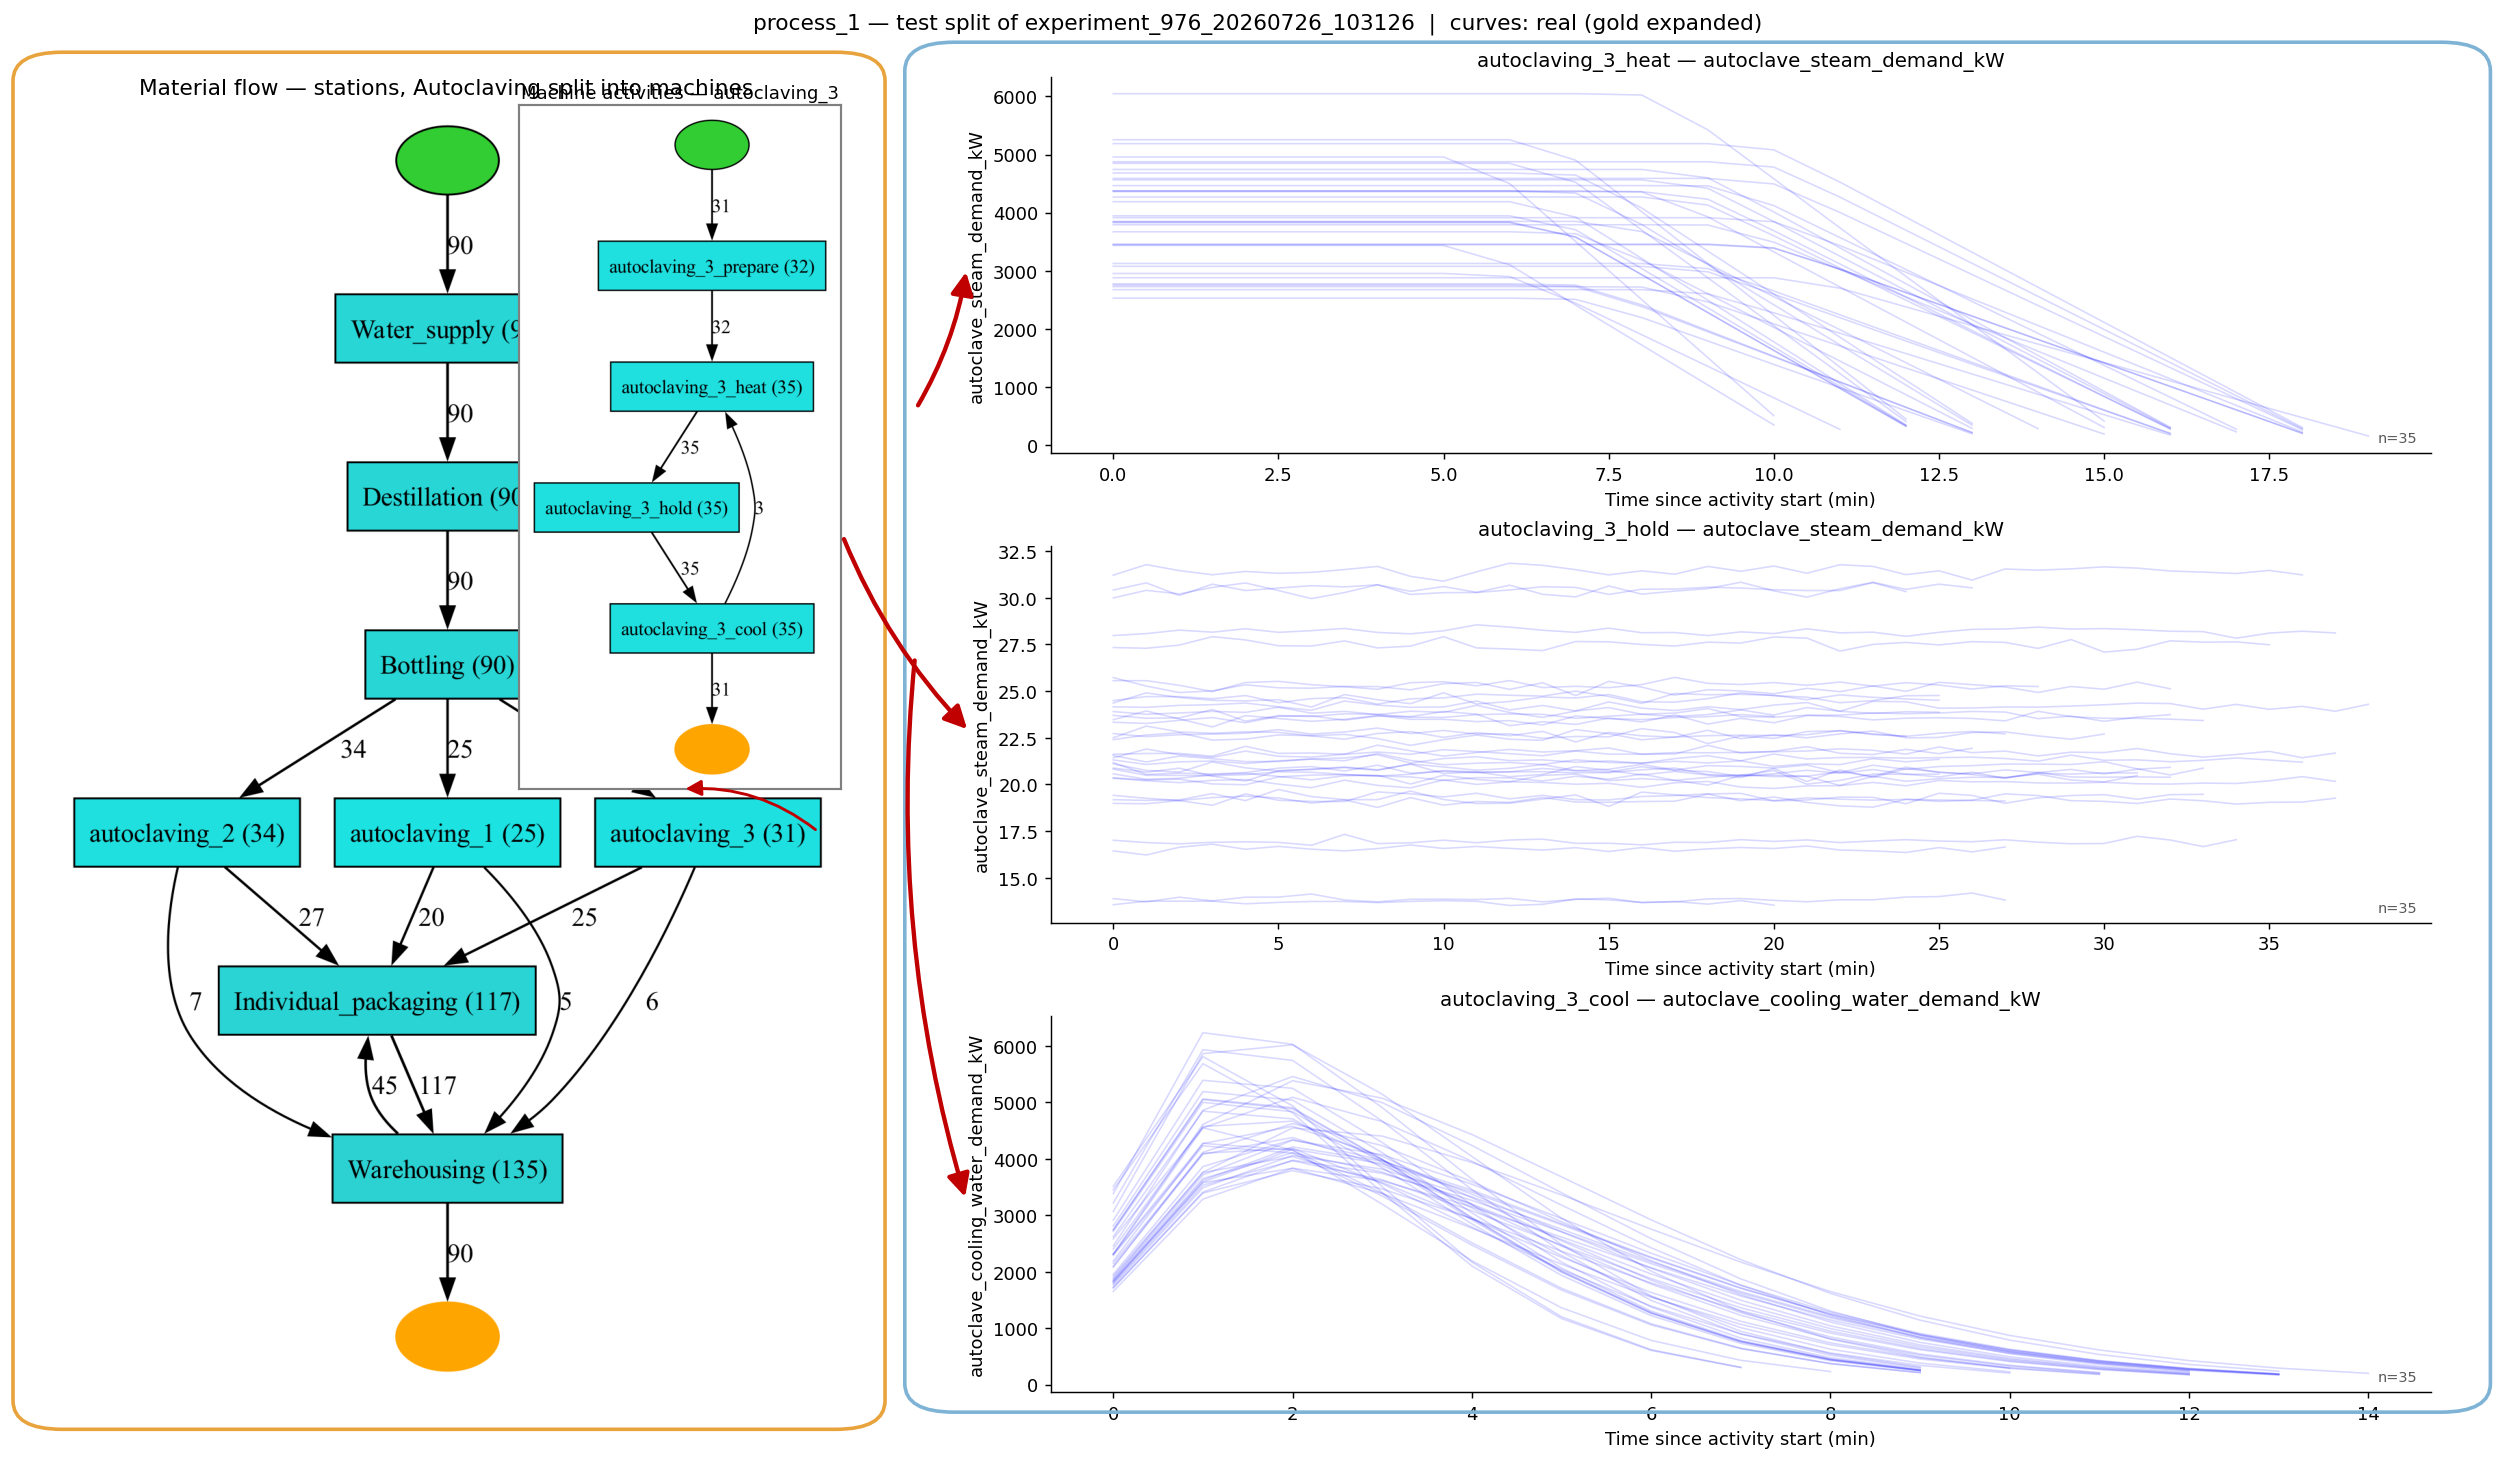

In [10]:
# ── Geometry ─────────────────────────────────────────────────────────────────
PAPER_W        = 19.0     # figure size, inches
PAPER_H        = 11.0
PAPER_INSET_W  = 0.13     # machine-net width, figure fraction (smaller than the material net)
PAPER_INSET_DX = 0.0      # nudge the inset left(-)/right(+) from its top-right anchor
PAPER_INSET_DY = 0.0      # nudge the inset down(-)/up(+)
PAPER_GAP      = 0.085    # gap between the process block and the profile block
PAPER_BOXES    = True     # rounded frames around the two blocks, as in the reference figure
ARROW_COLOR    = '#c00000'
BOX_COLORS     = ('#e8a33d', '#7fb3d5')   # process block, profile block

import shlex
from matplotlib.patches import ConnectionPatch, FancyBboxPatch


def net_node_positions(gviz, png):
    """activity -> (x, y, w, h) of its node box, as fractions of the rendered image.

    graphviz's 'plain' output gives the layout in inches without the page margins, so the
    padding is recovered from the PNG's own size -- no assumption about graphviz defaults."""
    try:
        txt = gviz.pipe(format='plain').decode('utf-8', 'replace')
    except Exception as exc:
        print(f'! graphviz layout unavailable ({exc}) — arrows anchor to the box edge')
        return {}
    rows = []
    W0 = H0 = None
    for line in txt.splitlines():
        try:
            parts = shlex.split(line)
        except ValueError:
            continue
        if not parts:
            continue
        if parts[0] == 'graph' and len(parts) >= 4:
            W0, H0 = float(parts[2]), float(parts[3])
        elif parts[0] == 'node' and len(parts) >= 7:
            rows.append([float(parts[2]), float(parts[3]), float(parts[4]), float(parts[5]), parts[6]])
    if W0 is None:
        return {}
    _h_px, _w_px = mpimg.imread(png).shape[:2]
    dpi = float(gviz.graph_attr.get('dpi', 96) or 96)
    pad_x, pad_y = (_w_px / dpi - W0) / 2, (_h_px / dpi - H0) / 2      # margins, inches
    W, H = W0 + 2 * pad_x, H0 + 2 * pad_y
    return {label.split(' (')[0].strip():
            ((x + pad_x) / W, 1 - (y + pad_y) / H, w / W, h / H)
            for x, y, w, h, label in rows}


node_xy = net_node_positions(gviz_machine, png_machine)
mat_node_xy = net_node_positions(gviz_material, png_material)
print('machine-net nodes located:', sorted(k for k in node_xy if not k.startswith('@@')))

# ── Figure ───────────────────────────────────────────────────────────────────
_mat, _mac = load_net_image(png_material), load_net_image(png_machine)
_a_mat, _a_mac = _mat.shape[0] / _mat.shape[1], _mac.shape[0] / _mac.shape[1]

fig = plt.figure(figsize=(PAPER_W, PAPER_H))

# material flow — axes sized to the image aspect, so the axes IS the image (no hidden padding,
# which is what lets the machine net be placed exactly on the material net's own whitespace)
_mx, _my, _mh = 0.012, 0.03, 0.90
_mw = _mh * PAPER_H / PAPER_W / _a_mat
ax_mat = fig.add_axes([_mx, _my, _mw, _mh])
ax_mat.imshow(_mat)
ax_mat.set_title(f'Material flow — stations, {MACHINE_STATION} split into machines', fontsize=12)
ax_mat.axis('off')

# machine activities — INSIDE the material net's top-right whitespace (above the machine row).
# Keeping it inside means the profile block starts right after the material net, which is what
# gives the activity->profile arrows room to actually travel.
_iw = PAPER_INSET_W
_ih = _iw * PAPER_W / PAPER_H * _a_mac
_ix = _mx + _mw - _iw + PAPER_INSET_DX
_iy = _my + _mh - _ih + PAPER_INSET_DY
ax_mac = fig.add_axes([_ix, _iy, _iw, _ih], zorder=5)
ax_mac.imshow(_mac)
ax_mac.set_title(f'Machine activities — {FOCUS_OBJECT}', fontsize=10, pad=4)
ax_mac.set_xticks([]); ax_mac.set_yticks([])
ax_mac.set_facecolor('white')
for _s in ax_mac.spines.values():         # rcParams hide top/right — force all four
    _s.set_visible(True)
    _s.set_edgecolor('0.5')
    _s.set_linewidth(1.2)

# leader line: the FOCUS_OBJECT box in the material flow → the inset that zooms into it
if FOCUS_OBJECT in mat_node_xy:
    _fx, _fy, _fw, _fh = mat_node_xy[FOCUS_OBJECT]
    _h_px_mat, _w_px_mat = _mat.shape[0], _mat.shape[1]
    fig.add_artist(ConnectionPatch(
        xyA=((_fx + _fw / 2) * _w_px_mat, _fy * _h_px_mat), coordsA=ax_mat.transData,  # node top edge
        xyB=(0.5, 0.0), coordsB=ax_mac.transAxes,                                      # inset bottom
        arrowstyle='-|>', mutation_scale=18, linewidth=1.6, color=ARROW_COLOR,
        connectionstyle='arc3,rad=0.20', shrinkA=3, shrinkB=3, zorder=6))
else:
    print(f'! {FOCUS_OBJECT!r} not located in material net — no leader line drawn')

# profiles — one panel per (activity, sensor), stacked in the right block
_rx = max(_mx + _mw, _ix + _iw) + PAPER_GAP
_rw = 0.975 - _rx
_n = max(len(panel_data), 1)
_pad = 0.065
_ph = (0.92 - _pad * (_n - 1)) / _n

panel_axes = []
for i, ((activity, sensor), d) in enumerate(panel_data.items()):
    ax = fig.add_axes([_rx, 0.95 - (i + 1) * _ph - i * _pad, _rw, _ph])
    draw_panel(ax, activity, sensor, d['curves'], d['n_total'])
    panel_axes.append((activity, ax))

# arrows: activity box in the machine net → its profile panel, ending right at the y-axis title
fig.canvas.draw()   # finalize layout so label positions below are correct
_renderer = fig.canvas.get_renderer()
_h_px, _w_px = _mac.shape[0], _mac.shape[1]
for activity, ax_p in panel_axes:
    if activity in node_xy:
        fx, fy, fw, fh = node_xy[activity]
        xy_a, coords_a = ((fx + fw) * _w_px, (fy + fh / 2) * _h_px), ax_mac.transData   # right edge of the box
    else:
        xy_a, coords_a = (1.0, 0.5), ax_mac.transAxes      # fallback: right edge of the box
    _lbl_bbox = ax_p.yaxis.label.get_window_extent(renderer=_renderer)
    xy_b = fig.transFigure.inverted().transform((_lbl_bbox.x0, (_lbl_bbox.y0 + _lbl_bbox.y1) / 2))
    fig.add_artist(ConnectionPatch(
        xyA=xy_a, coordsA=coords_a,
        xyB=xy_b, coordsB=fig.transFigure,
        arrowstyle='-|>', mutation_scale=26, linewidth=2.4, color=ARROW_COLOR,
        connectionstyle='arc3,rad=0.10', shrinkA=4, shrinkB=4, zorder=30))

# rounded frames around the two blocks
if PAPER_BOXES:
    _proc = (_mx - 0.012, _my - 0.022, (max(_mx + _mw, _ix + _iw) - _mx) + 0.026, _mh + 0.055)
    _prof = (_rx - 0.055, 0.02, _rw + 0.075, 0.95)
    for (bx, by, bw, bh), ec in zip((_proc, _prof), BOX_COLORS):
        fig.patches.append(FancyBboxPatch(
            (bx, by), bw, bh, boxstyle='round,pad=0.004,rounding_size=0.02',
            transform=fig.transFigure, facecolor='none', edgecolor=ec, linewidth=2.0, zorder=0))

fig.suptitle(f'{PROCESS} — {SPLIT} split of {run_dir.name}  |  curves: {SOURCE_LABEL}',
             fontsize=12, y=0.995)

if SAVE:
    _p = OUT / f'paper_figure_{PROCESS}_{FOCUS_OBJECT}_{SOURCE_TAG}_{SPLIT}.pdf'
    fig.savefig(_p, format='pdf', bbox_inches='tight', pad_inches=0.2)
    print(f'saved {_p}')
plt.show()


In [11]:
## 8. Next: the simulated curves of the best approach

# Set in cell 1 and re-run everything below it:

# ```python
RUN          = 'experiment_976'                        # a run with save_predicted_curves: True
CURVE_SOURCE = 'run_predicted'
SIM_SCOPE    = 'complete'                              # complete_curve_eval_results/<process>/<mode>/
SIM_MODE     = 'petri_net_heuristic_ml_plus_per_act'   # the best net + duration model
SIM_APPROACH = 'ml_external'                           # the best curve approach
# ```

# `CURVE_SOURCE = 'run_real'` with the same `RUN` gives the real curves out of the same file — a like-for-like
# reference for the simulated panels (it slices the real test log instead of the simulated one).
# Available modes / approaches for a run:

# ```python
sorted(p.name for p in (run_dir / 'complete_curve_eval_results' / PROCESS).iterdir())
sorted(p.name for p in (run_dir / 'complete_curve_eval_results' / PROCESS / SIM_MODE).glob('predicted_curves*.parquet'))
# ```


['predicted_curves.parquet',
 'predicted_curves_exemplar.parquet',
 'predicted_curves_median_activity_sensor.parquet',
 'predicted_curves_ml_external.parquet',
 'predicted_curves_ml_external_calib.parquet',
 'predicted_curves_ml_external_wcounts.parquet',
 'predicted_curves_ml_external_wmetric.parquet',
 'predicted_curves_ml_rawspace.parquet']

In [12]:
# What this run has to offer (empty output = the run saved no curves)
for scope, base in (('complete', run_dir / 'complete_curve_eval_results' / PROCESS),
                    ('schedule', run_dir / 'schedule_profile_eval_results' / PROCESS)):
    if not base.exists():
        print(f'{scope}: —')
        continue
    files = sorted(base.glob('**/predicted_curves*.parquet'))
    print(f'{scope}: {len(files)} curve file(s)')
    for p in files[:20]:
        print(f'   {p.relative_to(base)}')


complete: 72 curve file(s)
   petri_net_alpha/predicted_curves.parquet
   petri_net_alpha/predicted_curves_exemplar.parquet
   petri_net_alpha/predicted_curves_median_activity_sensor.parquet
   petri_net_alpha/predicted_curves_ml_external.parquet
   petri_net_alpha/predicted_curves_ml_external_calib.parquet
   petri_net_alpha/predicted_curves_ml_external_wcounts.parquet
   petri_net_alpha/predicted_curves_ml_external_wmetric.parquet
   petri_net_alpha/predicted_curves_ml_rawspace.parquet
   petri_net_alpha_ml_plus_global/predicted_curves.parquet
   petri_net_alpha_ml_plus_global/predicted_curves_exemplar.parquet
   petri_net_alpha_ml_plus_global/predicted_curves_median_activity_sensor.parquet
   petri_net_alpha_ml_plus_global/predicted_curves_ml_external.parquet
   petri_net_alpha_ml_plus_global/predicted_curves_ml_external_calib.parquet
   petri_net_alpha_ml_plus_global/predicted_curves_ml_external_wcounts.parquet
   petri_net_alpha_ml_plus_global/predicted_curves_ml_external_wmetric.

## 9. Simulated version — rebuild the same figure with predicted curves

Section 8 only reassigns the config variables (`RUN`, `CURVE_SOURCE`, `SIM_MODE`, `SIM_APPROACH`); it
doesn't rebuild `run_dir`, the test split, the two nets, or the curve/panel data that depend on them
— those still hold the **real** run's values until something re-derives them. That's why the simulated
process model and profiles were missing: nothing after cell 8 ever re-ran with the new config.

The cells below redo steps 1–7 (test split → material/machine layers → nets → curves → panels →
paper figure) for the config set in section 8, so this run's own `run_dir`/`cases`/nets/curves get
rebuilt from the **simulated** (`run_predicted`) source instead of reusing the real ones computed
above. This is the second and last figure the notebook produces.


In [13]:
# ── 9.1 re-resolve run_dir for the new RUN, reset the curve cache ────────────
_matches = [d for d in sorted(RESULTS.iterdir()) if d.is_dir() and (d.name == RUN or RUN in d.name)]
assert _matches, f'no run under {RESULTS} matching {RUN!r}'
run_dir = _matches[-1]
_curve_cache.clear()   # keyed off the previous run_dir — stale otherwise

print(f'run   : {run_dir.name}' + ('' if RUN == run_dir.name else f'   (latest match for {RUN!r})'))
print(f'source: CURVE_SOURCE={CURVE_SOURCE!r}, SIM_MODE={SIM_MODE!r}, SIM_APPROACH={SIM_APPROACH!r}')


run   : experiment_976_20260726_103126   (latest match for 'experiment_976')
source: CURVE_SOURCE='run_predicted', SIM_MODE='petri_net_heuristic_ml_plus_per_act', SIM_APPROACH='ml_external'


In [14]:
# ── 9.2 test split for this run (same logic as cell 1) ───────────────────────
_all_cases  = set(df_event_log['case_id'].dropna().unique())
_test_path  = run_dir / 'predicted_logs' / f'{PROCESS}_test_set.parquet'

if _test_path.exists():
    test_cases  = set(pd.read_parquet(_test_path)['case_id'].dropna().unique())
    split_source = f'predicted_logs/{PROCESS}_test_set.parquet'
else:
    _log = (run_dir / 'pipeline_execution.log')
    _m = re.search(r'SPLIT \((\d+)% train', _log.read_text()) if _log.exists() else None
    _ratio = int(_m.group(1)) / 100 if _m else 0.80
    _case_start = df_event_log.groupby('case_id')['timestamp_start'].min().sort_values()
    _n_train = max(1, int(len(_case_start) * _ratio))
    test_cases = set(_case_start.index[_n_train:])
    split_source = f'temporal split re-derived at train_ratio={_ratio:.2f} (run saved no test set)'

train_cases = _all_cases - test_cases
cases = {'test': test_cases, 'train': train_cases, 'all': _all_cases}[SPLIT]

print(f'split source : {split_source}')
print(f'train / test : {len(train_cases)} / {len(test_cases)} cases')
print(f'SPLIT={SPLIT!r} → {len(cases)} cases used below')


split source : predicted_logs/process_1_test_set.parquet
train / test : 2100 / 90 cases
SPLIT='test' → 90 cases used below


In [15]:
# ── 9.3 material-flow / machine-activity layers for this case set ────────────
el = (df_event_log[df_event_log['case_id'].isin(cases)]
      .sort_values(['case_id', 'timestamp_start'])
      .copy())

_focus_rows = el[el['object'] == FOCUS_OBJECT]
assert len(_focus_rows), f'{FOCUS_OBJECT!r} does not appear in this case set'
MACHINE_STATION = _focus_rows['station'].iloc[0]

df_material = el.copy()
df_material['flow_node'] = np.where(df_material['station'] == MACHINE_STATION,
                                    df_material['object'], df_material['station'])
_prev = df_material.groupby('case_id')['flow_node'].shift(1)
df_material = df_material[df_material['flow_node'] != _prev].copy()

df_machine = el[el['object'] == FOCUS_OBJECT].copy()

_order = (df_machine.assign(pos=df_machine.groupby('case_id').cumcount())
          .groupby('activity')['pos'].mean().sort_values())
MACHINE_ACTIVITIES = list(_order.index)

print(f'material flow  : {len(df_material)} handovers, nodes = '
      f'{list(df_material["flow_node"].value_counts().index)}')
print(f'machine layer  : {len(df_machine)} events on {FOCUS_OBJECT} '
      f'({df_machine["case_id"].nunique()} cases)')
print(f'  activities in process order: {MACHINE_ACTIVITIES}')


material flow  : 612 handovers, nodes = ['Warehousing', 'Individual_packaging', 'Water_supply', 'Destillation', 'Bottling', 'autoclaving_2', 'autoclaving_3', 'autoclaving_1']
machine layer  : 137 events on autoclaving_3 (31 cases)
  activities in process order: ['autoclaving_3_prepare', 'autoclaving_3_heat', 'autoclaving_3_hold', 'autoclaving_3_cool']


saved visuals/process_and_profiles/net_material_flow_process_1_test_sim.pdf


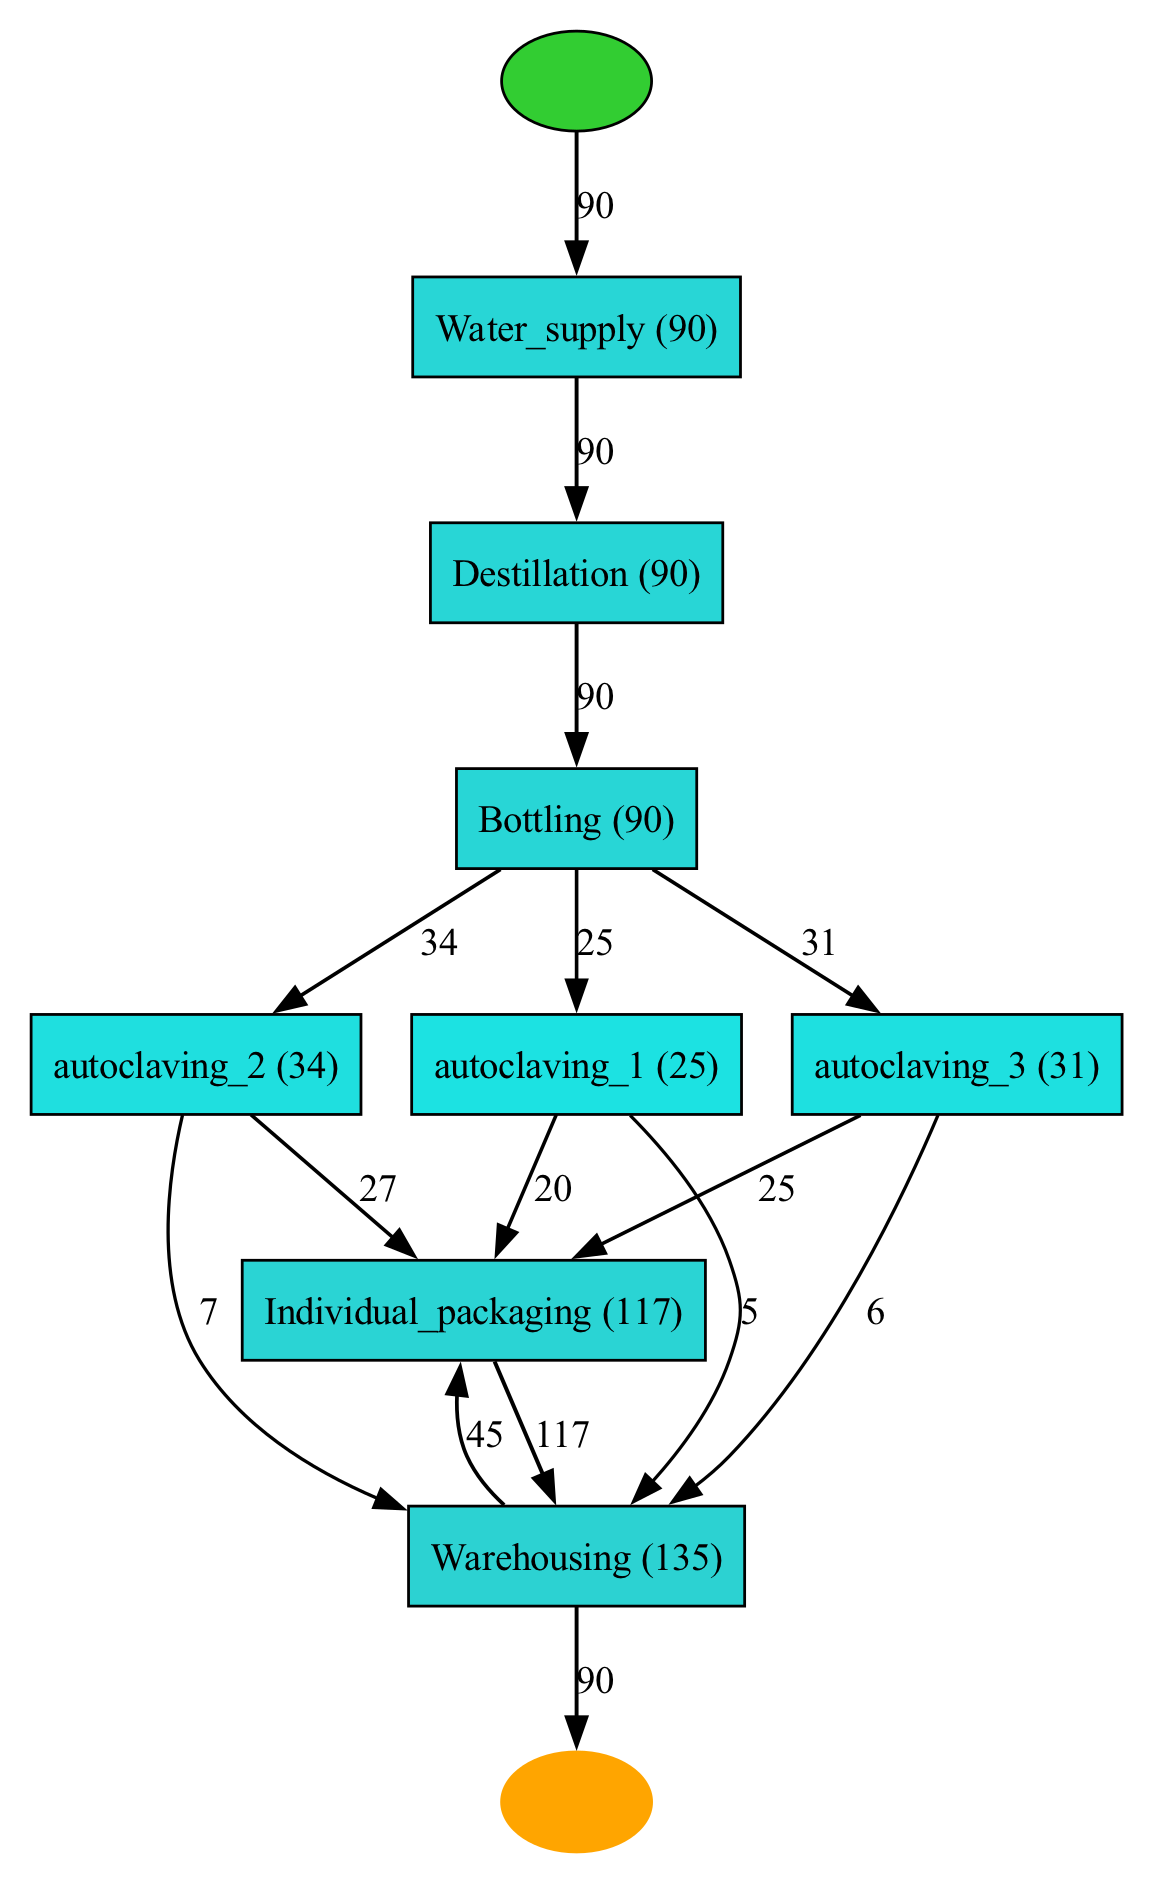

In [16]:
# ── 9.4 re-mine both nets for this run's layers ───────────────────────────────
png_material, gviz_material = heuristic_net(df_material, 'flow_node',
                                            f'net_material_flow_{PROCESS}_{SPLIT}_sim.pdf')
display(Image(filename=png_material))

saved visuals/process_and_profiles/net_machine_autoclaving_3_test_sim.pdf


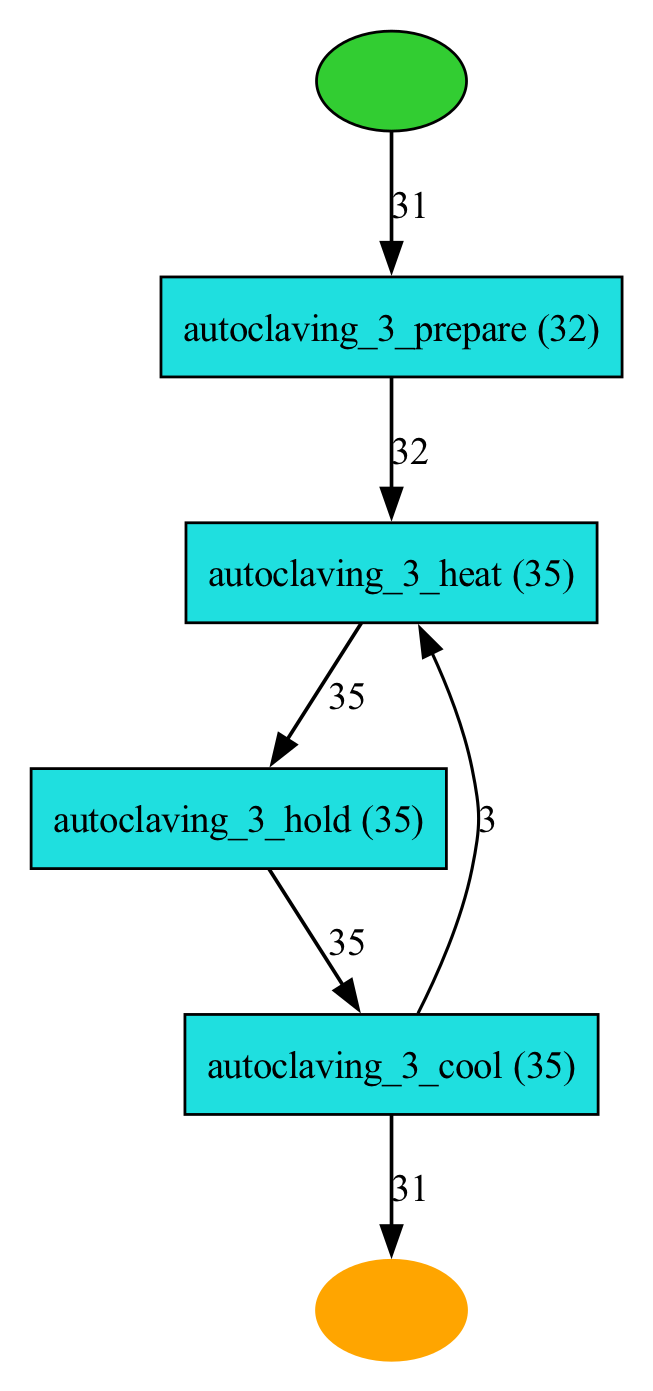

In [17]:
png_machine, gviz_machine = heuristic_net(df_machine, 'activity',
                                          f'net_machine_{FOCUS_OBJECT}_{SPLIT}_sim.pdf')
display(Image(filename=png_machine))


In [18]:
# ── 9.5 source label + panels for this config ─────────────────────────────────
if CURVE_SOURCE == 'real_expanded':
    SOURCE_TAG, SOURCE_LABEL = 'real', 'real (gold expanded)'
else:
    _series = SIM_SERIES or ('real' if CURVE_SOURCE == 'run_real' else 'predicted')
    SOURCE_TAG   = f'{_series}_{SIM_MODE}' + (f'_{SIM_APPROACH}' if SIM_APPROACH else '')
    SOURCE_LABEL = f'{_series} — {SIM_MODE}' + (f' / {SIM_APPROACH}' if SIM_APPROACH else '')
print(f'CURVE_SOURCE={CURVE_SOURCE!r} → {SOURCE_LABEL}')

if PANELS is None:
    panels = [(a, s) for a in MACHINE_ACTIVITIES if (s := dominant_sensor(a))]
else:
    panels = list(PANELS)

for a, s in panels:
    print(f'  {a:<28} {s}')


CURVE_SOURCE='run_predicted' → predicted — petri_net_heuristic_ml_plus_per_act / ml_external
  autoclaving_3_heat           autoclave_steam_demand_kW_energy_to_model
  autoclaving_3_hold           autoclave_steam_demand_kW_energy_to_model
  autoclaving_3_cool           autoclave_cooling_water_demand_kW_energy_to_model


In [19]:
# ── 9.6 curve data per panel, from the predicted series ──────────────────────
panel_data = {}
for activity, sensor in panels:
    curves = get_curves(activity, sensor)
    if len(curves) < 2:
        print(f'!! {activity} / {sensor}: only {len(curves)} curve(s) — skipped')
        continue
    n_total = len(curves)
    used = curves[:MAX_CURVES] if MAX_CURVES else curves
    panel_data[(activity, sensor)] = dict(curves=used, n_total=n_total)
    print(f'{activity:<28} {sensor:<45} n={len(used)}' + ('' if len(used) == n_total else f' of {n_total}'))

# ── why the simulated panels can hold fewer curves than the real ones ────────
# The curve file itself is complete (all test cases, both series).  What differs is the
# *simulated event log*: the model decides which of the parallel machines each batch goes to,
# and it does not reproduce the real load split across them.  So a machine the simulation
# under-uses simply has fewer occurrences to slice curves out of.
_real_log = pd.read_parquet(run_dir / 'predicted_logs' / f'{PROCESS}_test_set.parquet')
_sim_log  = _window_log(SIM_SERIES or 'predicted')
_cmp = pd.DataFrame({
    'real': _real_log[_real_log['case_id'].isin(cases)]['activity'].value_counts(),
    'sim':  _sim_log[_sim_log['case_id'].isin(cases)]['activity'].value_counts(),
}).fillna(0).astype(int)
_cmp = _cmp[_cmp.index.str.startswith(MACHINE_STATION.lower())].sort_index()
if len(_cmp):
    print(f'\noccurrences per {MACHINE_STATION} activity — real test log vs simulated log:')
    print(_cmp.to_string())
    print('→ the machine split is a property of the simulation, not of the curve extraction.')


curves from complete_curve_eval_results/process_1/petri_net_heuristic_ml_plus_per_act/predicted_curves_ml_external.parquet  | series: ['predicted', 'real']
windows from predicted_logs/process_1_petri_net_heuristic_ml_plus_per_act.parquet
autoclaving_3_heat           autoclave_steam_demand_kW_energy_to_model     n=7
autoclaving_3_hold           autoclave_steam_demand_kW_energy_to_model     n=7
autoclaving_3_cool           autoclave_cooling_water_demand_kW_energy_to_model n=7

occurrences per Autoclaving activity — real test log vs simulated log:
                       real  sim
activity                        
autoclaving_1_cool       24   36
autoclaving_1_heat       24   36
autoclaving_1_hold       24   36
autoclaving_1_prepare    22   36
autoclaving_2_cool       48   64
autoclaving_2_heat       48   74
autoclaving_2_hold       48   72
autoclaving_2_prepare    44   62
autoclaving_3_cool       31    7
autoclaving_3_heat       31    7
autoclaving_3_hold       31    7
autoclaving_3_prepar

machine-net nodes located: ['autoclaving_3_cool', 'autoclaving_3_heat', 'autoclaving_3_hold', 'autoclaving_3_prepare']


saved visuals/process_and_profiles/paper_figure_process_1_autoclaving_3_predicted_petri_net_heuristic_ml_plus_per_act_ml_external_test.pdf


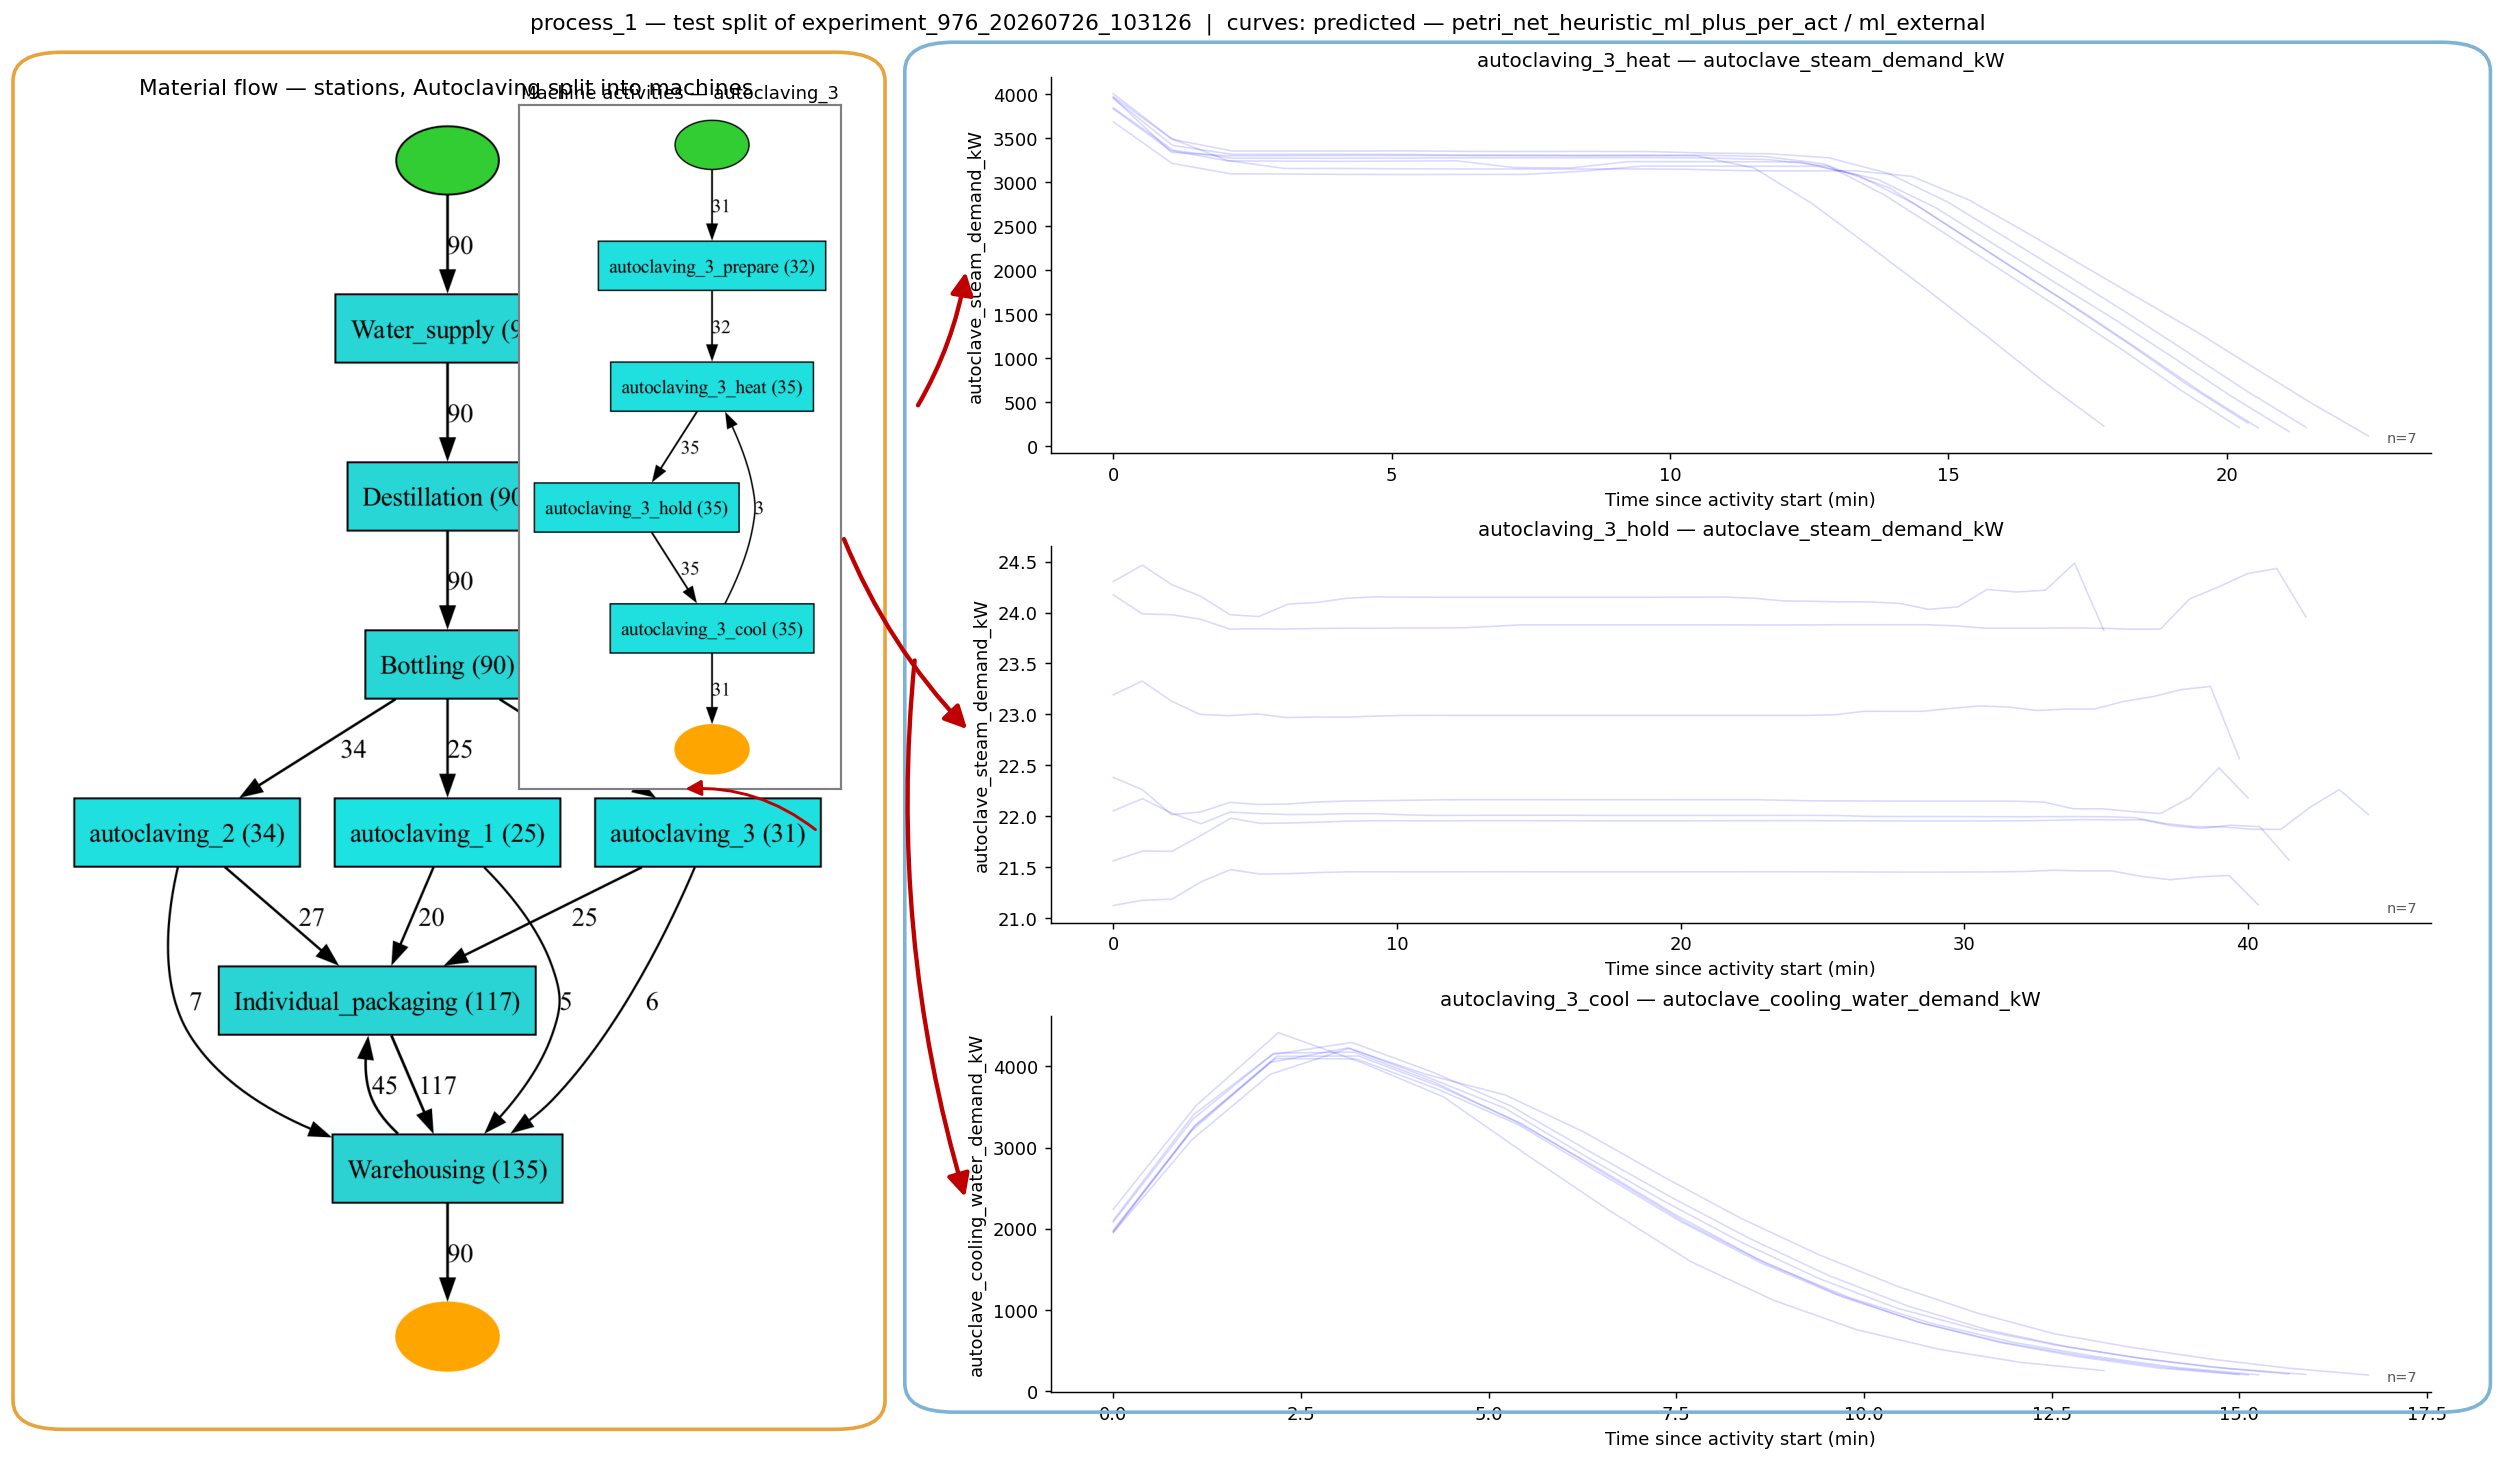

In [20]:
# ── 9.7 paper figure — simulated version ──────────────────────────────────────
node_xy = net_node_positions(gviz_machine, png_machine)
mat_node_xy = net_node_positions(gviz_material, png_material)
print('machine-net nodes located:', sorted(k for k in node_xy if not k.startswith('@@')))

_mat, _mac = load_net_image(png_material), load_net_image(png_machine)
_a_mat, _a_mac = _mat.shape[0] / _mat.shape[1], _mac.shape[0] / _mac.shape[1]

fig = plt.figure(figsize=(PAPER_W, PAPER_H))

_mx, _my, _mh = 0.012, 0.03, 0.90
_mw = _mh * PAPER_H / PAPER_W / _a_mat
ax_mat = fig.add_axes([_mx, _my, _mw, _mh])
ax_mat.imshow(_mat)
ax_mat.set_title(f'Material flow — stations, {MACHINE_STATION} split into machines', fontsize=12)
ax_mat.axis('off')

_iw = PAPER_INSET_W
_ih = _iw * PAPER_W / PAPER_H * _a_mac
_ix = _mx + _mw - _iw + PAPER_INSET_DX
_iy = _my + _mh - _ih + PAPER_INSET_DY
ax_mac = fig.add_axes([_ix, _iy, _iw, _ih], zorder=5)
ax_mac.imshow(_mac)
ax_mac.set_title(f'Machine activities — {FOCUS_OBJECT}', fontsize=10, pad=4)
ax_mac.set_xticks([]); ax_mac.set_yticks([])
ax_mac.set_facecolor('white')
for _s in ax_mac.spines.values():
    _s.set_visible(True)
    _s.set_edgecolor('0.5')
    _s.set_linewidth(1.2)

if FOCUS_OBJECT in mat_node_xy:
    _fx, _fy, _fw, _fh = mat_node_xy[FOCUS_OBJECT]
    _h_px_mat, _w_px_mat = _mat.shape[0], _mat.shape[1]
    fig.add_artist(ConnectionPatch(
        xyA=((_fx + _fw / 2) * _w_px_mat, _fy * _h_px_mat), coordsA=ax_mat.transData,
        xyB=(0.5, 0.0), coordsB=ax_mac.transAxes,
        arrowstyle='-|>', mutation_scale=18, linewidth=1.6, color=ARROW_COLOR,
        connectionstyle='arc3,rad=0.20', shrinkA=3, shrinkB=3, zorder=6))
else:
    print(f'! {FOCUS_OBJECT!r} not located in material net — no leader line drawn')

_rx = max(_mx + _mw, _ix + _iw) + PAPER_GAP
_rw = 0.975 - _rx
_n = max(len(panel_data), 1)
_pad = 0.065
_ph = (0.92 - _pad * (_n - 1)) / _n

panel_axes = []
for i, ((activity, sensor), d) in enumerate(panel_data.items()):
    ax = fig.add_axes([_rx, 0.95 - (i + 1) * _ph - i * _pad, _rw, _ph])
    draw_panel(ax, activity, sensor, d['curves'], d['n_total'])
    panel_axes.append((activity, ax))

fig.canvas.draw()
_renderer = fig.canvas.get_renderer()
_h_px, _w_px = _mac.shape[0], _mac.shape[1]
for activity, ax_p in panel_axes:
    if activity in node_xy:
        fx, fy, fw, fh = node_xy[activity]
        xy_a, coords_a = ((fx + fw) * _w_px, (fy + fh / 2) * _h_px), ax_mac.transData
    else:
        xy_a, coords_a = (1.0, 0.5), ax_mac.transAxes
    _lbl_bbox = ax_p.yaxis.label.get_window_extent(renderer=_renderer)
    xy_b = fig.transFigure.inverted().transform((_lbl_bbox.x0, (_lbl_bbox.y0 + _lbl_bbox.y1) / 2))
    fig.add_artist(ConnectionPatch(
        xyA=xy_a, coordsA=coords_a,
        xyB=xy_b, coordsB=fig.transFigure,
        arrowstyle='-|>', mutation_scale=26, linewidth=2.4, color=ARROW_COLOR,
        connectionstyle='arc3,rad=0.10', shrinkA=4, shrinkB=4, zorder=30))

if PAPER_BOXES:
    _proc = (_mx - 0.012, _my - 0.022, (max(_mx + _mw, _ix + _iw) - _mx) + 0.026, _mh + 0.055)
    _prof = (_rx - 0.055, 0.02, _rw + 0.075, 0.95)
    for (bx, by, bw, bh), ec in zip((_proc, _prof), BOX_COLORS):
        fig.patches.append(FancyBboxPatch(
            (bx, by), bw, bh, boxstyle='round,pad=0.004,rounding_size=0.02',
            transform=fig.transFigure, facecolor='none', edgecolor=ec, linewidth=2.0, zorder=0))

fig.suptitle(f'{PROCESS} — {SPLIT} split of {run_dir.name}  |  curves: {SOURCE_LABEL}',
             fontsize=12, y=0.995)

if SAVE:
    _p = OUT / f'paper_figure_{PROCESS}_{FOCUS_OBJECT}_{SOURCE_TAG}_{SPLIT}.pdf'
    fig.savefig(_p, format='pdf', bbox_inches='tight', pad_inches=0.2)
    print(f'saved {_p}')
plt.show()
